Step 1: YOLO-to-Multi-Label Conversion

In [ ]:
import os
import pandas as pd
from google.colab import drive

# ount Google Drive
drive.mount('/content/drive')

# Set your dataset base directory here
base_path = '/content/drive/MyDrive/Tomato_Dataset'

# Class names from your data.yaml
class_names = ['Bacterial Spot', 'Early_Blight', 'Healthy', 'Late_blight', 'Leaf Mold', 'Target_Spot', 'black spot']
num_classes = len(class_names)

# Helper to process one split (train/valid/test)
def process_split(split):
    image_dir = os.path.join(base_path, split, 'images')
    label_dir = os.path.join(base_path, split, 'labels')
    data = []

    for filename in os.listdir(label_dir):
        if filename.endswith('.txt'):
            label_path = os.path.join(label_dir, filename)
            image_filename = filename.replace('.txt', '.jpg')  # assuming .jpg images
            image_path = os.path.join(image_dir, image_filename)

            # Initialize a zero label vector
            label_vector = [0] * num_classes

            # Read YOLO annotations
            with open(label_path, 'r') as f:
                for line in f:
                    class_id = int(line.strip().split()[0])
                    label_vector[class_id] = 1  # multi-label

            data.append([image_path] + label_vector)

    return pd.DataFrame(data, columns=['image_path'] + class_names)

# Process all splits
df_train = process_split('train')
df_valid = process_split('valid')
df_test = process_split('test')

#  Merge all into one CSV (or keep separate)
df_all = pd.concat([df_train, df_valid, df_test], ignore_index=True)

# Save to CSV
output_csv_path = os.path.join(base_path, 'tomato_multilabel_dataset.csv')
df_all.to_csv(output_csv_path, index=False)

print(f"CSV saved to: {output_csv_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CSV saved to: /content/drive/MyDrive/Tomato_Dataset/tomato_multilabel_dataset.csv


DataLoader & Transform setup

In [ ]:
import os
import pandas as pd
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch

# Step 1: Clear GPU memory
import gc
torch.cuda.empty_cache()
gc.collect()

# Step 2: Read the cleaned CSV
csv_path = os.path.join(base_path, 'tomato_multilabel_dataset.csv')
df = pd.read_csv(csv_path)

# Step 3: Remove broken image paths
df = df[df['image_path'].apply(lambda x: Path(x).exists())].reset_index(drop=True)

# Step 4: Split the dataset
df_train = df[df['image_path'].str.contains('/train/')]
df_valid = df[df['image_path'].str.contains('/valid/')]
df_test  = df[df['image_path'].str.contains('/test/')]

# Step 5: Define image transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Step 6: Define custom dataset class
class MultiLabelTomatoDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
        self.labels = dataframe.iloc[:, 1:].values.astype('float32')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.iloc[idx, 0]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(self.labels[idx])
        return image, label

# Step 7: DataLoaders (Batch size = 32)
train_loader = DataLoader(MultiLabelTomatoDataset(df_train, transform=transform), batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(MultiLabelTomatoDataset(df_valid, transform=transform), batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(MultiLabelTomatoDataset(df_test,  transform=transform), batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(df_train)} | Valid: {len(df_valid)} | Test: {len(df_test)} — all paths verified ")

Train: 645 | Valid: 61 | Test: 31 — all paths verified 


Step 3: Build the ConvNeXtV2 model

In [ ]:
import torch
import torch.nn as nn
import timm  # Make sure: pip install timm

# Device config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load ConvNeXtV2 with correct classifier
model = timm.create_model("convnextv2_base.fcmae_ft_in22k_in1k", pretrained=True)
model.reset_classifier(num_classes=7)  # replaces the final layer with output=7
model = model.to(device)

# Define loss & optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Model ready with ConvNeXtV2 + 7 output neurons (multi-label)")

Using device: cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/355M [00:00<?, ?B/s]

Model ready with ConvNeXtV2 + 7 output neurons (multi-label)


Training & Validation

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import os

# Folder to save best model
os.makedirs("saved_models", exist_ok=True)

# Evaluation function
def evaluate(model, dataloader, threshold=0.5):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).float()

            y_true.append(labels.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    return acc, prec, rec, f1

# Training loop
def train(model, train_loader, valid_loader, criterion, optimizer, num_epochs=20):
    best_f1 = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        acc, prec, rec, f1 = evaluate(model, valid_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}] — Loss: {running_loss:.4f} | Acc: {acc:.4f} | Prec: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), "saved_models/best_convnextv2_multilabel.pth")
            print(" Best model saved!")

# Start training
train(model, train_loader, valid_loader, criterion, optimizer, num_epochs=10)

Epoch [1/10] — Loss: 6.3104 | Acc: 0.6557 | Prec: 0.8072 | Recall: 0.6008 | F1: 0.6643
 Best model saved!
Epoch [2/10] — Loss: 2.0041 | Acc: 0.7869 | Prec: 0.8263 | Recall: 0.6792 | F1: 0.7261
 Best model saved!
Epoch [3/10] — Loss: 0.9803 | Acc: 0.8197 | Prec: 0.9268 | Recall: 0.8114 | F1: 0.8429
 Best model saved!
Epoch [4/10] — Loss: 0.4740 | Acc: 0.8361 | Prec: 0.9281 | Recall: 0.7913 | F1: 0.8315
Epoch [5/10] — Loss: 0.2511 | Acc: 0.8525 | Prec: 0.9281 | Recall: 0.8270 | F1: 0.8519
 Best model saved!
Epoch [6/10] — Loss: 0.1464 | Acc: 0.8361 | Prec: 0.9281 | Recall: 0.7913 | F1: 0.8315
Epoch [7/10] — Loss: 0.0909 | Acc: 0.8361 | Prec: 0.9281 | Recall: 0.7913 | F1: 0.8315
Epoch [8/10] — Loss: 0.0729 | Acc: 0.8361 | Prec: 0.9281 | Recall: 0.7913 | F1: 0.8315
Epoch [9/10] — Loss: 0.0615 | Acc: 0.8361 | Prec: 0.9210 | Recall: 0.7913 | F1: 0.8284
Epoch [10/10] — Loss: 0.0550 | Acc: 0.8361 | Prec: 0.9210 | Recall: 0.7913 | F1: 0.8284


In [ ]:
from sklearn.metrics import classification_report

# Load best saved model
model.load_state_dict(torch.load("saved_models/best_convnextv2_multilabel.pth"))
model.eval()

# Evaluate on test set
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Classification Report (per class)
target_names = ['Bacterial Spot', 'Early_Blight', 'Healthy', 'Late_blight', 'Leaf Mold', 'Target_Spot', 'black spot']
print("Classification Report on Test Set:\n")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

Classification Report on Test Set:

                precision    recall  f1-score   support

Bacterial Spot       1.00      0.50      0.67         2
  Early_Blight       0.88      1.00      0.94        15
       Healthy       1.00      1.00      1.00         7
   Late_blight       1.00      0.89      0.94         9
     Leaf Mold       1.00      0.75      0.86         4
   Target_Spot       0.67      1.00      0.80         2
    black spot       0.89      0.89      0.89         9

     micro avg       0.92      0.92      0.92        48
     macro avg       0.92      0.86      0.87        48
  weighted avg       0.93      0.92      0.91        48
   samples avg       0.95      0.94      0.94        48



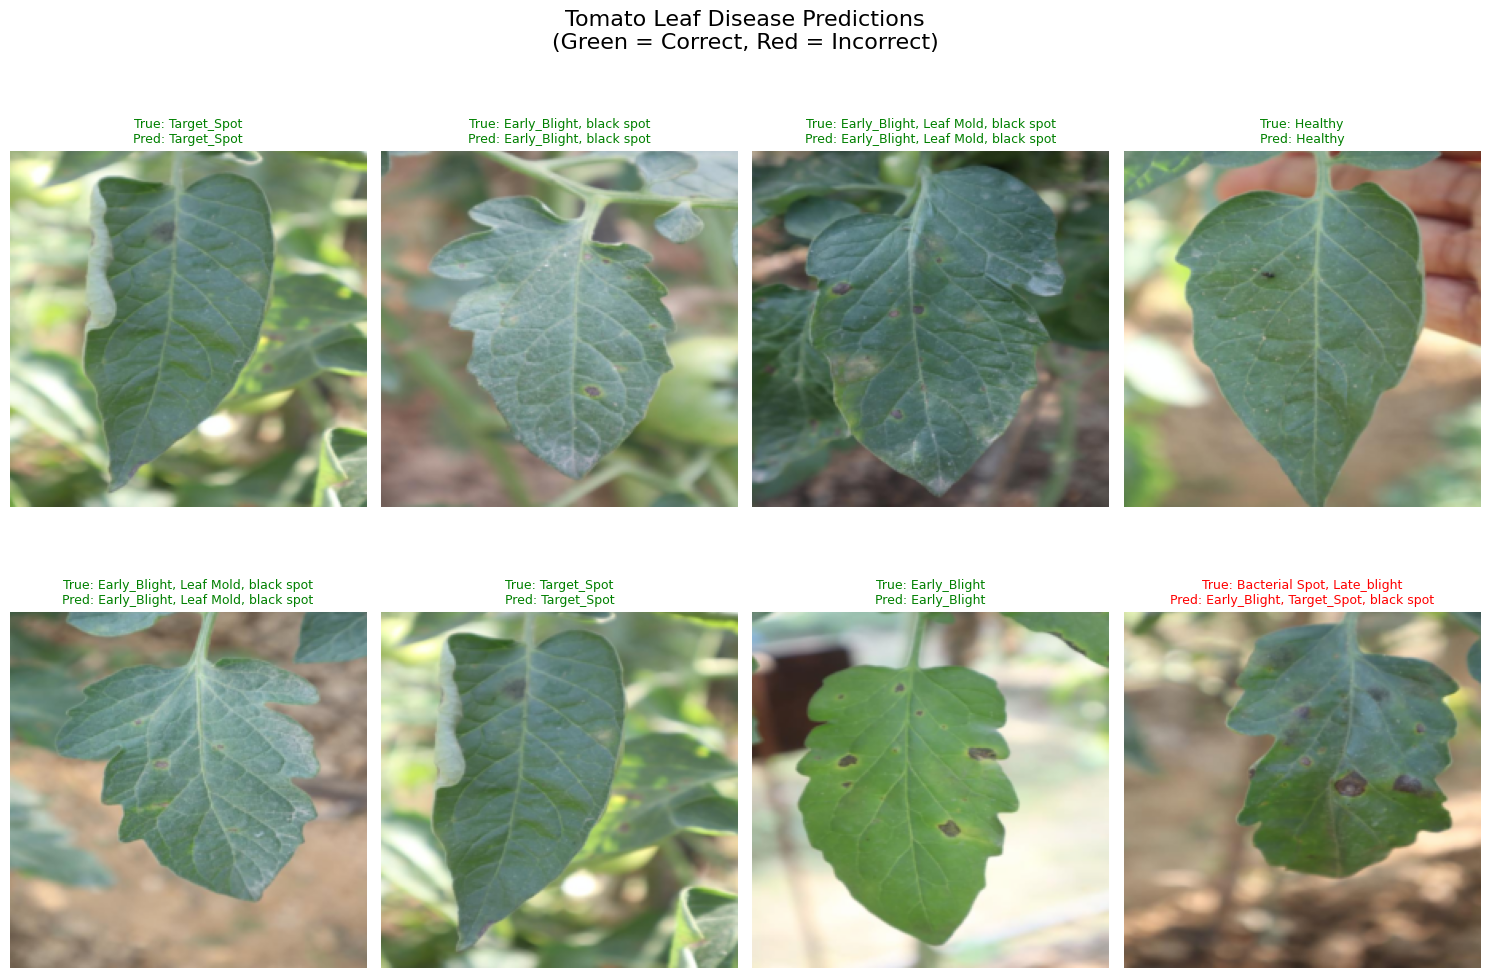

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Disease class names
class_names = ['Bacterial Spot', 'Early_Blight', 'Healthy', 'Late_blight', 'Leaf Mold', 'Target_Spot', 'black spot']

# Pick a few samples from test set
samples_to_show = 8
model.eval()

images_shown = 0

plt.figure(figsize=(15, 10))

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float().cpu()

        for i in range(images.size(0)):
            if images_shown >= samples_to_show:
                break

            image = images[i].permute(1, 2, 0).numpy()
            image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # unnormalize
            image = np.clip(image, 0, 1)

            true_labels = [class_names[j] for j in range(len(class_names)) if labels[i][j] == 1]
            pred_labels = [class_names[j] for j in range(len(class_names)) if preds[i][j] == 1]

            plt.subplot(2, 4, images_shown + 1)
            plt.imshow(image)
            plt.axis('off')
            plt.title(f"True: {', '.join(true_labels)}\nPred: {', '.join(pred_labels)}",
                      fontsize=9, color='green' if true_labels == pred_labels else 'red')

            images_shown += 1

        if images_shown >= samples_to_show:
            break

plt.tight_layout()
plt.suptitle("Tomato Leaf Disease Predictions\n(Green = Correct, Red = Incorrect)", fontsize=16, y=1.05)
plt.show()

evaluate_fitness_pso function

In [ ]:
def evaluate_fitness_pso(params, train_loader, valid_loader):
    lr, dropout, weight_decay = params

    # Build model
    model = timm.create_model("convnext_tiny", pretrained=True, drop_rate=dropout)
    model.reset_classifier(num_classes=7)
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    model.train()
    train_iter = iter(train_loader)
    for _ in range(2):  # Train on 2 batches for quick fitness test
        try:
            images, labels = next(train_iter)
        except StopIteration:
            break
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluate
    model.eval()
    y_true, y_pred = [], []
    valid_iter = iter(valid_loader)
    with torch.no_grad():
        for _ in range(2):  # Evaluate on 2 batches
            try:
                images, labels = next(valid_iter)
            except StopIteration:
                break
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    from sklearn.metrics import f1_score
    return f1_score(y_true, y_pred, average='macro', zero_division=0)

PSO Setup

In [ ]:
import numpy as np
import random

# Define the bounds for the hyperparameters
param_bounds = {
    'learning_rate': (1e-5, 1e-2),
    'dropout_rate': (0.1, 0.5),
    'weight_decay': (0.0, 1e-2)
}

# Define particle class
class Particle:
    def __init__(self):
        self.position = {
            'learning_rate': random.uniform(*param_bounds['learning_rate']),
            'dropout_rate': random.uniform(*param_bounds['dropout_rate']),
            'weight_decay': random.uniform(*param_bounds['weight_decay'])
        }
        self.velocity = {
            key: 0 for key in self.position
        }
        self.best_position = self.position.copy()
        self.best_score = float('inf')  # because we aim to minimize validation loss

# PSO parameters
n_particles = 8
n_iterations = 10
w = 0.5     # inertia
c1 = 1.0    # cognitive
c2 = 2.0    # social

# Initialize swarm
swarm = [Particle() for _ in range(n_particles)]
global_best_position = swarm[0].position.copy()
global_best_score = float('inf')

evaluate_model function

In [ ]:
import timm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.nn.functional as F

# Assume your train_loader and val_loader are already defined
# And your device is already set (e.g., device = torch.device("cuda" if torch.cuda.is_available() else "cpu"))

def evaluate_model(params, train_loader, val_loader, device):
    lr = params['learning_rate']
    dropout = params['dropout_rate']
    weight_decay = params['weight_decay']

    model = timm.create_model("convnext_tiny", pretrained=True, drop_rate=dropout)
    model.reset_classifier(num_classes=7)
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    model.train()
    for epoch in range(1):  # Train for just 1 epoch to save time
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    return avg_val_loss

In [ ]:
# Final PSO optimization loop
for iteration in range(n_iterations):
    print(f"\nPSO Iteration {iteration + 1}/{n_iterations}")

    for particle in swarm:
        # Evaluate fitness
        fitness = evaluate_model(particle.position, train_loader, valid_loader, device)
        print(f"Fitness for particle: {fitness:.4f}, Position: {particle.position}")

        # Personal best update
        if fitness < particle.best_score:
            particle.best_score = fitness
            particle.best_position = particle.position.copy()
            print("Updated personal best.")

        # Global best update
        if fitness < global_best_score:
            global_best_score = fitness
            global_best_position = particle.position.copy()
            print("Updated global best!")

    # Update velocity and position of particles
    for particle in swarm:
        for key in particle.position:
            r1 = random.random()
            r2 = random.random()

            cognitive = c1 * r1 * (particle.best_position[key] - particle.position[key])
            social = c2 * r2 * (global_best_position[key] - particle.position[key])

            particle.velocity[key] = w * particle.velocity[key] + cognitive + social
            particle.position[key] += particle.velocity[key]

            # Clamp the position within the allowed range
            low, high = param_bounds[key]
            particle.position[key] = max(min(particle.position[key], high), low)



PSO Iteration 1/10


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Fitness for particle: 4.8147, Position: {'learning_rate': 0.007012497055021168, 'dropout_rate': 0.24404811874371274, 'weight_decay': 0.006744480899499848}
Updated personal best.
Updated global best!
Fitness for particle: 3.0170, Position: {'learning_rate': 0.006618931593641694, 'dropout_rate': 0.10098942902515806, 'weight_decay': 0.008858185496772758}
Updated personal best.
Updated global best!
Fitness for particle: 3.3321, Position: {'learning_rate': 0.00830508268280704, 'dropout_rate': 0.10100779488160204, 'weight_decay': 0.0057734114545237095}
Updated personal best.
Fitness for particle: 3.1658, Position: {'learning_rate': 0.0042024382559137366, 'dropout_rate': 0.20970934992800772, 'weight_decay': 0.005690708748917279}
Updated personal best.
Fitness for particle: 2.8552, Position: {'learning_rate': 0.007720279973245497, 'dropout_rate': 0.12066659796387157, 'weight_decay': 0.0007821907134905537}
Updated personal best.
Updated global best!
Fitness for particle: 3.3374, Position: {'lea

In [ ]:
print("\n Optimization Complete!")
print(f" Best Validation Loss: {global_best_score:.4f}")
print(f" Best Hyperparameters: {global_best_position}")



 Optimization Complete!
 Best Validation Loss: 2.7152
 Best Hyperparameters: {'learning_rate': 0.00627546979233932, 'dropout_rate': 0.12035825227852101, 'weight_decay': 0.0004879558477517345}


Final Training Code

In [ ]:
# Final training with best parameters
best_params = global_best_position  # or manually assign as below
# best_params = {'learning_rate': 1e-05, 'dropout_rate': 0.3491, 'weight_decay': 0.00518}

model = timm.create_model("convnext_tiny", pretrained=True, drop_rate=best_params['dropout_rate'])
model.reset_classifier(num_classes=7)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),
                             lr=best_params['learning_rate'],
                             weight_decay=best_params['weight_decay'])

# You can set a higher epoch value like 10 or more if GPU is available
n_epochs = 20

for epoch in range(n_epochs):
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {train_loss/len(train_loader):.4f}")

# Save the final model
torch.save(model.state_dict(), "best_pso_convnext_model.pth")
print("Final model trained and saved.")


Epoch [1/20], Loss: 5.3494
Epoch [2/20], Loss: 3.1195
Epoch [3/20], Loss: 2.5212
Epoch [4/20], Loss: 2.4736
Epoch [5/20], Loss: 2.5306
Epoch [6/20], Loss: 2.5394
Epoch [7/20], Loss: 2.5639
Epoch [8/20], Loss: 2.5218
Epoch [9/20], Loss: 2.5419
Epoch [10/20], Loss: 2.5631
Epoch [11/20], Loss: 2.4600
Epoch [12/20], Loss: 2.5028
Epoch [13/20], Loss: 2.4884
Epoch [14/20], Loss: 2.4815
Epoch [15/20], Loss: 2.5052
Epoch [16/20], Loss: 2.5044
Epoch [17/20], Loss: 2.4452
Epoch [18/20], Loss: 2.4974
Epoch [19/20], Loss: 2.4855
Epoch [20/20], Loss: 2.4759
Final model trained and saved.


Evaluate on Test Set

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.48      1.00      0.65        15
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00         5
           5       0.00      0.00      0.00         2

    accuracy                           0.48        31
   macro avg       0.10      0.20      0.13        31
weighted avg       0.23      0.48      0.32        31



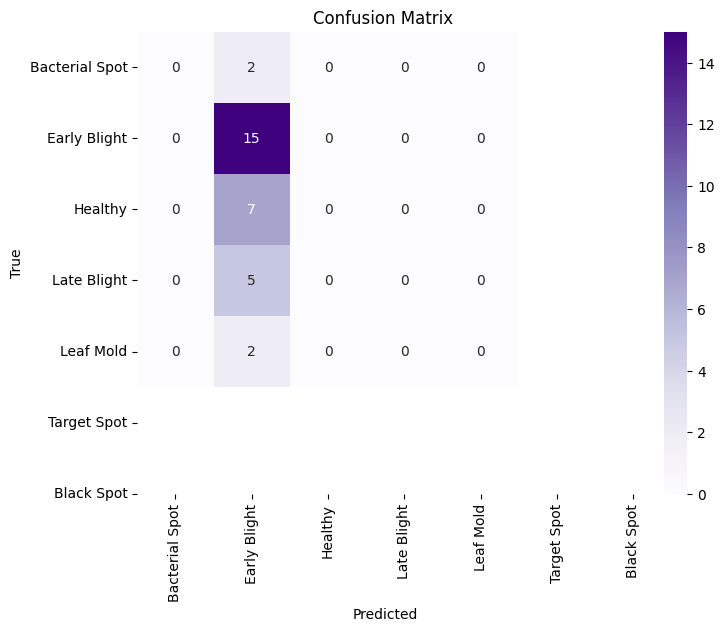

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load model if not already loaded
model.load_state_dict(torch.load("best_pso_convnext_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)           # shape: (batch,)
        true_labels = torch.argmax(labels, dim=1)       # convert one-hot to class indices

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(true_labels.cpu().numpy())

# Now both lists are in class index format

# Classification Report
print("Classification Report:")
print(classification_report(all_labels, all_preds, zero_division=0))

# Confusion Matrix
class_names = ['Bacterial Spot', 'Early Blight', 'Healthy', 'Late Blight', 'Leaf Mold', 'Target Spot', 'Black Spot']
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix ")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
from google.colab import files
files.download("best_pso_convnext_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>